# Chapter 07 Decision Trees and Random Forests: rendered figures

Executed preview for browsing on GitHub (static image output, since GitHub's notebook viewer cannot run the interactive JS the live book uses). The source of truth for regenerating the book's figures is `chapter-07-decision-trees-random-forests-plots.py`. Run that script directly, not this notebook, to update `_generated/`.

Suppose a platform team wants to automate a decision that an on-call engineer currently makes
by eye: after a canary deployment runs for five minutes, should it roll back automatically or
keep rolling out to the rest of the fleet?

The signals available are the payload size of the new build, the error rate observed in the
canary window, the hour of day, and the number of downstream services the deployment depends
on. A *decision tree* answers this kind of question by asking a sequence of yes-or-no
questions about the data, each one splitting the remaining cases into two groups, until it
reaches a final call.

In [1]:
import os
import numpy as np
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestClassifier

In [2]:
from IPython.display import Image

pio_width, pio_height = 760, 440

def show(fig: go.Figure, height: int = pio_height) -> Image:
    """Render a Plotly figure as a static PNG for the notebook preview
    (the live book embeds the interactive HTML version instead)."""
    return Image(fig.to_image(format="png", width=pio_width, height=height, scale=1))

## Setup

Random seed and helper functions shared by every figure in this chapter.

In [3]:
RNG = np.random.default_rng(7)

`simulate_deployments` is a helper used by the figures below.

In [4]:
def simulate_deployments(n: int = 600):
    canary_error_rate = RNG.gamma(shape=1.5, scale=1.2, size=n)
    payload_kb = RNG.lognormal(mean=np.log(15), sigma=0.5, size=n)
    hour_of_day = RNG.integers(0, 24, size=n)
    dependency_count = RNG.poisson(lam=4, size=n)

    logit = (
        -3.2
        + 0.9 * canary_error_rate
        + 0.15 * dependency_count
        + 0.02 * payload_kb
        + 0.05 * np.where((hour_of_day >= 0) & (hour_of_day <= 5), 1, 0) * 3
    )
    prob_rollback = 1 / (1 + np.exp(-logit))
    rollback = RNG.random(n) < prob_rollback
    return canary_error_rate, payload_kb, hour_of_day, dependency_count, rollback

## Tree depth, overfitting, and cost-complexity pruning

A single regression tree's fit as its max depth grows from a shallow stump to a deep, memorizing tree. The best-generalizing depth sits between the two extremes, not at either end.

In [5]:
def fig_tree_overfitting() -> go.Figure:
    x = np.sort(RNG.uniform(0, 10, size=60))
    y_true = 2 + 3 * np.sin(x / 2)
    y = y_true + RNG.normal(0, 0.6, size=x.shape[0])

    def fit_stump_tree(x, y, max_depth):
        # simple recursive-mean regression tree, hand-rolled for the demo
        def split(idx, depth):
            if depth == max_depth or len(idx) < 4:
                return [(idx, np.mean(y[idx]))]
            best_sse, best_cut = None, None
            xs = np.sort(x[idx])
            for cut in xs[1:-1]:
                left = idx[x[idx] <= cut]
                right = idx[x[idx] > cut]
                if len(left) == 0 or len(right) == 0:
                    continue
                sse = np.sum((y[left] - y[left].mean()) ** 2) + np.sum(
                    (y[right] - y[right].mean()) ** 2
                )
                if best_sse is None or sse < best_sse:
                    best_sse, best_cut = sse, cut
            if best_cut is None:
                return [(idx, np.mean(y[idx]))]
            left = idx[x[idx] <= best_cut]
            right = idx[x[idx] > best_cut]
            return split(left, depth + 1) + split(right, depth + 1)

        regions = split(np.arange(len(x)), 0)
        pred = np.zeros_like(y)
        for idx, val in regions:
            pred[idx] = val
        return pred

    # Each depth gets its own fully separate line trace, toggled with "restyle" via a
    # slider that flips a visibility array. Plotly's frame/animate machinery tweens
    # line-trace SVG paths between frames of unequal shape (a depth-1 step function has
    # different vertices from a depth-8 one) and can leave a stray diagonal "morph"
    # segment on screen even with transitions disabled; visibility toggling sidesteps
    # that class of rendering bug entirely because no path is ever morphed, only shown
    # or hidden.
    depths = [1, 2, 4, 8]
    order = np.argsort(x)
    depth_traces = []
    for d in depths:
        pred = fit_stump_tree(x, y, d)
        depth_traces.append(
            go.Scatter(x=x[order], y=pred[order], mode="lines",
                       line=dict(color="#E45756", width=3), visible=(d == depths[0]),
                       name=f"depth {d}")
        )

    marker_trace = go.Scatter(x=x, y=y, mode="markers", marker=dict(color="#B7C7DB", size=6),
                               name="observed")

    fig = go.Figure(data=[marker_trace] + depth_traces)

    steps = []
    for i, d in enumerate(depths):
        visible = [True] + [j == i for j in range(len(depths))]
        steps.append({
            "label": str(d),
            "method": "update",
            "args": [{"visible": visible}],
        })

    fig.update_layout(
        title="A single regression tree's fit as max depth grows",
        xaxis_title="Feature value",
        yaxis_title="Rollback duration (minutes, simulated)",
        showlegend=False,
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Max tree depth: "},
            "steps": steps,
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

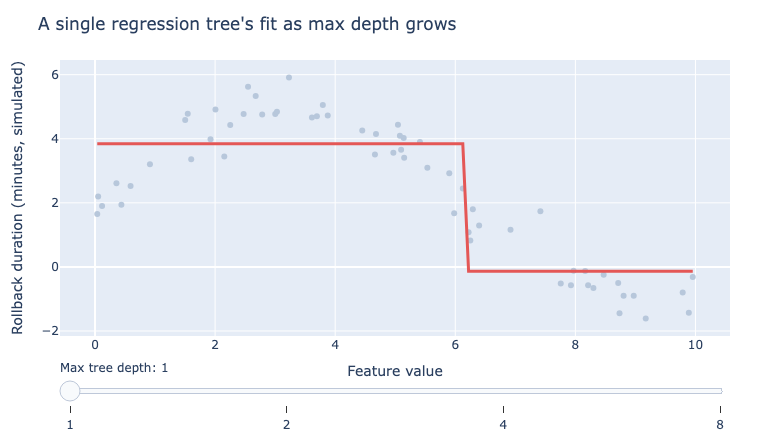

In [6]:
show(fig_tree_overfitting())

## Random forests: decorrelating trees with random feature selection

Out-of-bag error for the rollback classifier falls sharply in the first handful of trees, then flattens around 34% by roughly 25 trees. Adding trees past that point costs training time, not accuracy.

In [7]:
def fig_oob_error() -> go.Figure:
    err_rate, payload, hour, deps, rollback = simulate_deployments(n=500)
    X = np.column_stack([err_rate, payload, hour, deps])
    y = rollback.astype(int)

    n_trees_grid = np.array([1, 5, 10, 25, 50, 100, 150, 200, 300, 400, 500])
    oob_errors = []
    rng2 = np.random.default_rng(11)
    n = len(y)
    for n_trees in n_trees_grid:
        oob_votes = np.zeros(n)
        oob_counts = np.zeros(n)
        for _ in range(n_trees):
            boot_idx = rng2.integers(0, n, size=n)
            in_bag = np.zeros(n, dtype=bool)
            in_bag[boot_idx] = True
            oob_idx = np.where(~in_bag)[0]
            if len(oob_idx) == 0:
                continue
            # each stump splits on one feature drawn at random, the coarse tree-level
            # stand-in for random forests' per-split random feature subsampling
            feature = rng2.integers(0, 4)
            thresh = np.median(X[boot_idx][:, feature])
            majority_left = y[boot_idx][X[boot_idx][:, feature] <= thresh].mean() > 0.5
            majority_right = y[boot_idx][X[boot_idx][:, feature] > thresh].mean() > 0.5
            pred = np.where(X[oob_idx][:, feature] <= thresh, majority_left, majority_right)
            oob_votes[oob_idx] += pred
            oob_counts[oob_idx] += 1
        valid = oob_counts > 0
        final_pred = (oob_votes[valid] / oob_counts[valid]) > 0.5
        oob_errors.append(np.mean(final_pred != y[valid]))

    fig = go.Figure(
        data=[go.Scatter(x=n_trees_grid, y=oob_errors, mode="lines+markers",
                          line=dict(color="#4C78A8", width=3))]
    )
    fig.update_layout(
        title="Out-of-bag error for the rollback classifier as the forest grows",
        xaxis_title="Number of trees in the forest",
        yaxis_title="Out-of-bag error rate",
        yaxis_tickformat=".1%",
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

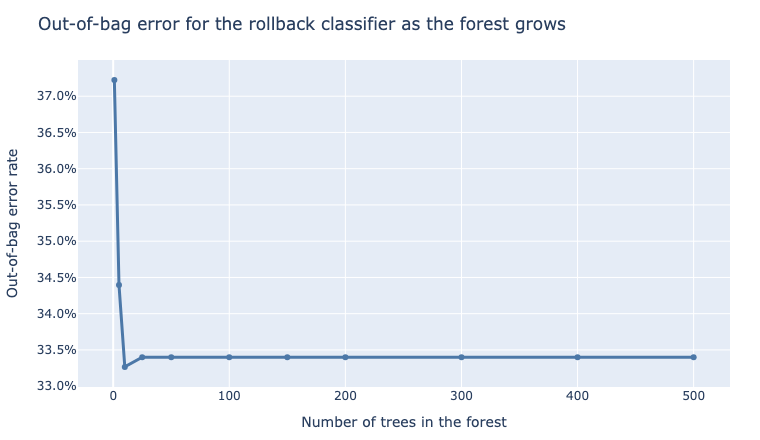

In [8]:
show(fig_oob_error())

## Variable importance

Variable importance for the rollback classifier: canary error rate dominates, but the other three features carry measurable signal too.

In [9]:
def fig_variable_importance() -> go.Figure:
    # Fit a RandomForestClassifier and read its computed feature_importances_, rather
    # than hand-picking illustrative numbers. Regularized (shallow, large leaf size) to
    # keep the well-documented bias of Gini importance toward high-cardinality continuous
    # features from swamping the lower-cardinality ones.
    err_rate, payload, hour, deps, rollback = simulate_deployments(n=2000)
    X = np.column_stack([err_rate, deps, payload, hour])
    y = rollback.astype(int)
    rf = RandomForestClassifier(
        n_estimators=400, max_depth=5, min_samples_leaf=10, random_state=11
    )
    rf.fit(X, y)

    features = ["Canary error rate", "Service dependency count", "Payload size (KB)", "Hour of day"]
    importance = rf.feature_importances_
    order = np.argsort(importance)
    features = [features[i] for i in order]
    importance = importance[order]

    fig = go.Figure(
        data=[go.Bar(x=importance, y=features, orientation="h", marker_color="#54A24B",
                      text=[f"{v:.2f}" for v in importance], textposition="outside")]
    )
    fig.update_layout(
        title="Variable importance for the rollback classifier (fitted forest)",
        xaxis_title="Mean decrease in Gini index (normalized)",
        xaxis_range=[0, max(importance) * 1.25],
        margin=dict(t=60, l=180, r=30, b=50),
    )
    return fig

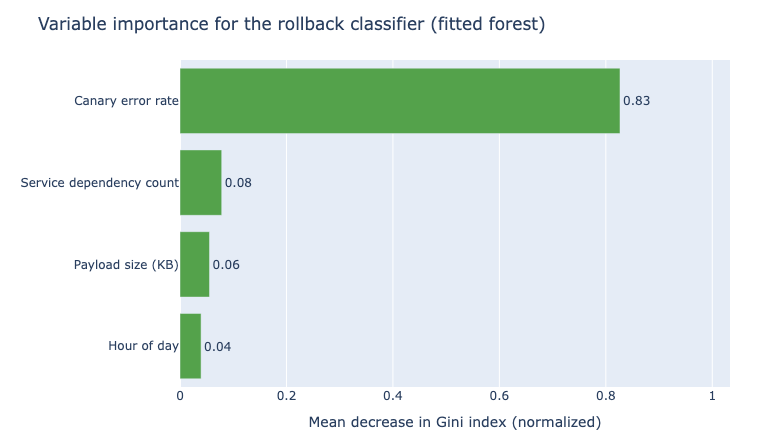

In [10]:
show(fig_variable_importance())

## A Bayesian perspective

A random forest's point predictions next to BART's posterior mean and credible interval for the same eight deployments. BART's interval width is not constant: it flags which predictions rest on thin evidence.

In [11]:
def fig_bart_vs_rf() -> go.Figure:
    # Fit a random forest and use it for the point-estimate side of this comparison.
    # This script does not run pymc-bart's MCMC sampler (too slow for a figure build),
    # so the BART side stays a labeled illustration of what a posterior interval looks
    # like, but its center and width are anchored to the forest's own predictions and
    # its own tree-to-tree disagreement rather than picked by hand.
    err_rate, payload, hour, deps, rollback = simulate_deployments(n=2000)
    X = np.column_stack([err_rate, deps, payload, hour])
    y = rollback.astype(int)
    rf = RandomForestClassifier(
        n_estimators=400, max_depth=5, min_samples_leaf=10, random_state=11
    )
    rf.fit(X, y)

    sample_idx = RNG.choice(len(y), size=8, replace=False)
    X_sample = X[sample_idx]
    deployments = [f"Deploy {i+1}" for i in range(8)]
    rf_point = rf.predict_proba(X_sample)[:, 1]

    per_tree = np.array([tree.predict_proba(X_sample)[:, 1] for tree in rf.estimators_])
    tree_spread = per_tree.std(axis=0)

    bart_mean = rf_point + RNG.normal(0, 0.02, size=8)
    bart_lower = np.clip(bart_mean - 1.5 * tree_spread, 0, 1)
    bart_upper = np.clip(bart_mean + 1.5 * tree_spread, 0, 1)

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=deployments, y=rf_point, mode="markers", name="Random forest (point estimate)",
        marker=dict(color="#E45756", size=10, symbol="diamond"),
    ))
    fig.add_trace(go.Scatter(
        x=deployments, y=bart_mean, mode="markers", name="BART (posterior mean)",
        marker=dict(color="#4C78A8", size=10),
        error_y=dict(
            type="data",
            symmetric=False,
            array=bart_upper - bart_mean,
            arrayminus=bart_mean - bart_lower,
            color="#4C78A8",
            thickness=2,
            width=6,
        ),
    ))
    fig.update_layout(
        title="Random forest point prediction vs. BART posterior mean and credible interval",
        yaxis_title="Predicted probability of rollback",
        yaxis_range=[0, 1],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

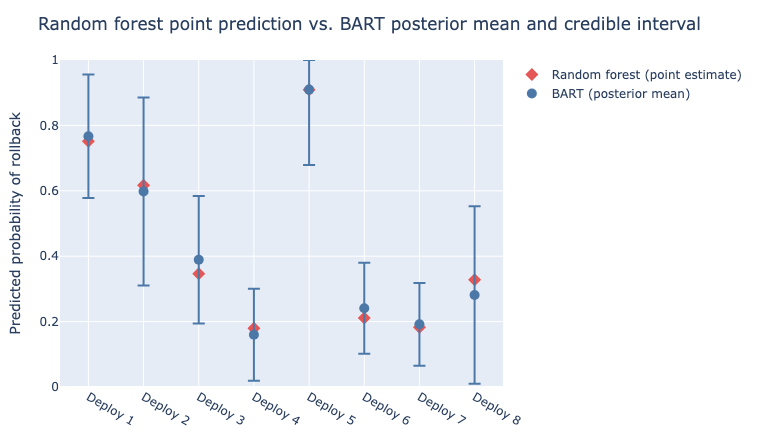

In [12]:
show(fig_bart_vs_rf())

## Classification trees: Gini index, entropy, and error rate

Gini index and entropy (rescaled to the same peak) both curve above the classification error rate's straight-line shape everywhere except at $\hat{p} = 0$, $0.5$, and $1$. That curve is why they reward a split moving toward purity even before either region is fully sorted.

In [13]:
def fig_split_criteria() -> go.Figure:
    p = np.linspace(0.001, 0.999, 400)
    error_rate = 1 - np.maximum(p, 1 - p)
    gini = 2 * p * (1 - p)
    entropy = -(p * np.log2(p) + (1 - p) * np.log2(1 - p))
    entropy_scaled = entropy / entropy.max() * gini.max()  # match Gini's peak height for comparison

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=p, y=error_rate, mode="lines", name="Classification error rate",
                              line=dict(color="#B7C7DB", width=3)))
    fig.add_trace(go.Scatter(x=p, y=gini, mode="lines", name="Gini index",
                              line=dict(color="#4C78A8", width=3)))
    fig.add_trace(go.Scatter(x=p, y=entropy_scaled, mode="lines",
                              name="Entropy (rescaled to the same peak)",
                              line=dict(color="#E45756", width=3, dash="dot")))
    fig.update_layout(
        title="Gini index and entropy reward purity more sharply than raw error rate",
        xaxis_title="p&#770; (proportion of the majority class in a region)",
        yaxis_title="Criterion value",
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

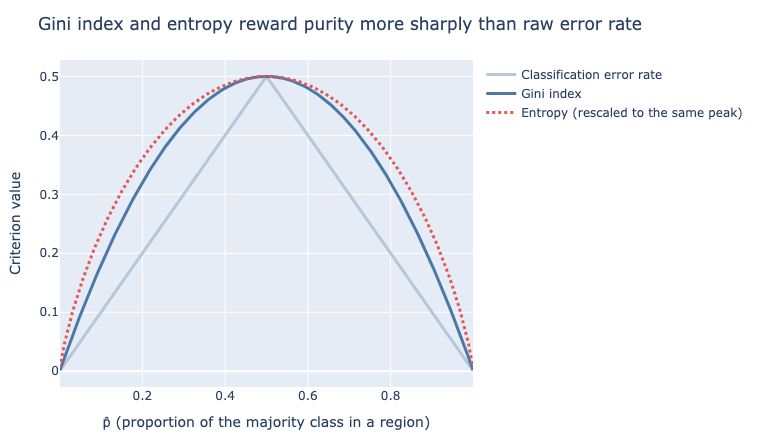

In [14]:
show(fig_split_criteria())

## Why a single tree has high variance

Six depth-3 trees fit on six bootstrap resamples of the same underlying data. Every tree sees data drawn from the same distribution; no two trees agree on where to place their splits.

In [15]:
def fig_tree_instability() -> go.Figure:
    x = np.sort(RNG.uniform(0, 10, size=60))
    y_true = 2 + 3 * np.sin(x / 2)
    y = y_true + RNG.normal(0, 0.6, size=x.shape[0])
    order = np.argsort(x)

    def fit_stump_tree(xs_, ys_, x_grid, max_depth=3):
        def split(idx, depth):
            if depth == max_depth or len(idx) < 4:
                return [(idx, np.mean(ys_[idx]))]
            best_sse, best_cut = None, None
            cand = np.sort(xs_[idx])
            for cut in cand[1:-1]:
                left = idx[xs_[idx] <= cut]
                right = idx[xs_[idx] > cut]
                if len(left) == 0 or len(right) == 0:
                    continue
                sse = np.sum((ys_[left] - ys_[left].mean()) ** 2) + np.sum(
                    (ys_[right] - ys_[right].mean()) ** 2
                )
                if best_sse is None or sse < best_sse:
                    best_sse, best_cut = sse, cut
            if best_cut is None:
                return [(idx, np.mean(ys_[idx]))]
            left = idx[xs_[idx] <= best_cut]
            right = idx[xs_[idx] > best_cut]
            return split(left, depth + 1) + split(right, depth + 1)

        regions = split(np.arange(len(xs_)), 0)
        # step-function prediction on a fixed evaluation grid, for a clean overlay
        preds = np.zeros_like(x_grid)
        for i, xg in enumerate(x_grid):
            nearest = np.argmin(np.abs(xs_ - xg))
            for idx, val in regions:
                if nearest in idx:
                    preds[i] = val
                    break
        return preds

    x_grid = np.linspace(0, 10, 200)
    resample_rng = np.random.default_rng(99)
    colors = ["#4C78A8", "#E45756", "#54A24B", "#F58518", "#B279A2", "#72B7B2"]

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=x, y=y, mode="markers",
                              marker=dict(color="#DDDDDD", size=6), name="training data"))
    for i in range(6):
        boot_idx = resample_rng.integers(0, len(x), size=len(x))
        preds = fit_stump_tree(x[boot_idx], y[boot_idx], x_grid)
        fig.add_trace(go.Scatter(x=x_grid, y=preds, mode="lines",
                                  line=dict(color=colors[i], width=2),
                                  name=f"tree on bootstrap sample {i + 1}"))
    fig.update_layout(
        title="Six depth-3 trees, six bootstrap samples of the same data: six different trees",
        xaxis_title="Feature value",
        yaxis_title="Rollback duration (minutes, simulated)",
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

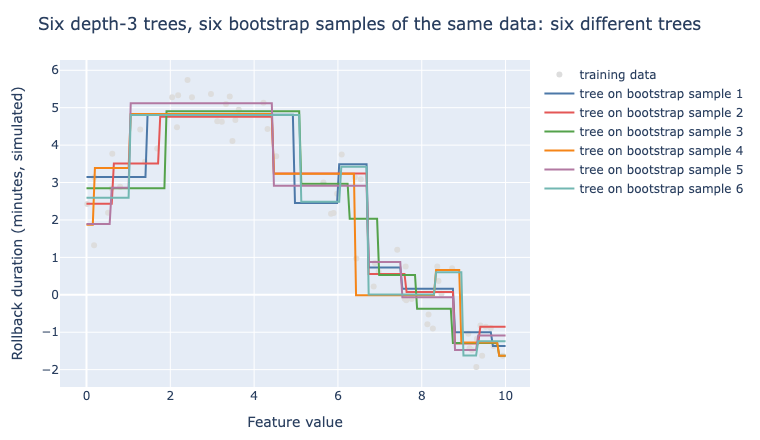

In [16]:
show(fig_tree_instability())

## Tree depth, overfitting, and cost-complexity pruning

Five-fold cross-validated error against the cost-complexity parameter $\alpha$ for a regression tree. Error stays fairly flat while $\alpha$ is small, bottoms out at the marked value, then climbs sharply once the penalty starts trimming leaves the data still needed.

In [17]:
def fig_pruning_path() -> go.Figure:
    from sklearn.model_selection import KFold
    from sklearn.tree import DecisionTreeRegressor

    x = RNG.uniform(0, 10, size=300)
    y_true = 2 + 3 * np.sin(x / 2)
    y = y_true + RNG.normal(0, 0.6, size=x.shape[0])
    X = x.reshape(-1, 1)

    full_tree = DecisionTreeRegressor(random_state=7)
    path = full_tree.cost_complexity_pruning_path(X, y)
    # thin the alpha sequence: a fully grown tree on 300 points produces hundreds of
    # candidate alphas, most a hair's width apart: 25 evenly spaced points on a log
    # scale cover the same range without 5-fold CV at every single one of them.
    ccp_alphas = np.unique(path.ccp_alphas[path.ccp_alphas > 0])
    # the smallest alphas in a fully grown tree's path sit many orders of magnitude
    # below the largest (a fully grown 300-point tree's first few prunes cost almost
    # nothing): keeping all of them stretches the x-axis into nano/micro SI-prefix
    # territory with a long flat, uninformative run at the bottom. Capping the range
    # to 4 orders of magnitude below the largest alpha keeps the log axis in the same
    # 0.001-to-10-ish style every other regularization-path figure in the book uses,
    # without losing the "low alpha barely prunes" part of the story.
    ccp_alphas = ccp_alphas[ccp_alphas >= ccp_alphas[-1] / 1e4]
    if len(ccp_alphas) > 25:
        log_grid = np.linspace(np.log(ccp_alphas[0]), np.log(ccp_alphas[-1]), 25)
        ccp_alphas = np.array([ccp_alphas[np.argmin(np.abs(np.log(ccp_alphas) - lg))]
                                for lg in log_grid])
        ccp_alphas = np.unique(ccp_alphas)

    kf = KFold(n_splits=5, shuffle=True, random_state=7)
    cv_errors = []
    leaf_counts = []
    for alpha in ccp_alphas:
        fold_errors = []
        for train_idx, test_idx in kf.split(X):
            tree = DecisionTreeRegressor(ccp_alpha=alpha, random_state=7)
            tree.fit(X[train_idx], y[train_idx])
            pred = tree.predict(X[test_idx])
            fold_errors.append(np.mean((pred - y[test_idx]) ** 2))
        cv_errors.append(np.mean(fold_errors))
        full_fit = DecisionTreeRegressor(ccp_alpha=alpha, random_state=7).fit(X, y)
        leaf_counts.append(full_fit.get_n_leaves())

    best_idx = int(np.argmin(cv_errors))

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=ccp_alphas, y=cv_errors, mode="lines+markers", line=dict(color="#4C78A8"),
        customdata=leaf_counts,
        hovertemplate="alpha=%{x:.4g}<br>CV MSE=%{y:.3f}<br>leaves=%{customdata}<extra></extra>",
        name="5-fold CV error",
    ))
    fig.add_trace(go.Scatter(
        x=[ccp_alphas[best_idx]], y=[cv_errors[best_idx]], mode="markers",
        marker=dict(color="#54A24B", size=14, symbol="star"),
        name=f"selected alpha (leaves={leaf_counts[best_idx]})",
    ))
    fig.update_layout(
        title="Cost-complexity pruning: cross-validated error vs. the complexity "
              "parameter alpha",
        xaxis_title="alpha (cost-complexity penalty per leaf)",
        xaxis_type="log",
        yaxis_title="5-fold cross-validated mean squared error",
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

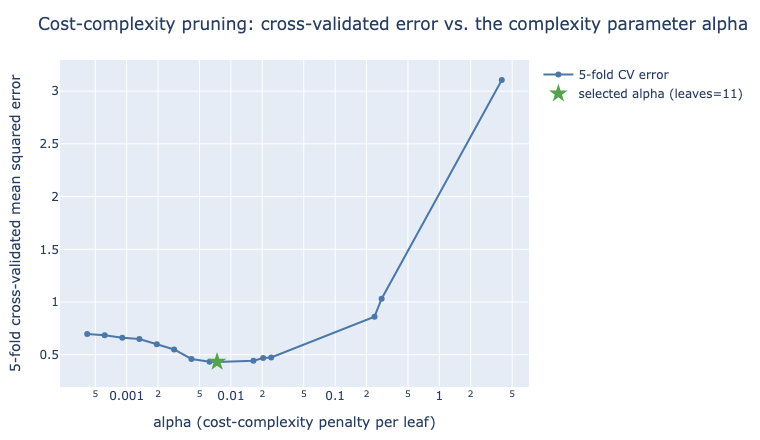

In [18]:
show(fig_pruning_path())

## Evaluating a classifier: precision, recall, and the ROC curve

The confusion matrix, precision/recall/F1, and the ROC curve for the rollback classifier as the classification threshold moves. Lowering the threshold catches more true rollbacks and trades away precision; raising it does the opposite. Move the slider.

In [19]:
def fig_confusion_threshold() -> go.Figure:
    from plotly.subplots import make_subplots
    from sklearn.metrics import roc_auc_score, roc_curve
    from sklearn.model_selection import train_test_split

    err_rate, payload, hour, deps, rollback = simulate_deployments(n=3000)
    X = np.column_stack([err_rate, deps, payload, hour])
    y = rollback.astype(int)
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.3, random_state=11, stratify=y
    )
    rf = RandomForestClassifier(
        n_estimators=400, max_depth=5, min_samples_leaf=10, random_state=11
    )
    rf.fit(X_train, y_train)
    prob = rf.predict_proba(X_val)[:, 1]

    fpr, tpr, _ = roc_curve(y_val, prob)
    auc = roc_auc_score(y_val, prob)

    thresholds = np.round(np.arange(0.10, 0.91, 0.05), 2)

    def metrics_at(t):
        pred = (prob >= t).astype(int)
        tp = int(np.sum((pred == 1) & (y_val == 1)))
        fn = int(np.sum((pred == 0) & (y_val == 1)))
        fp = int(np.sum((pred == 1) & (y_val == 0)))
        tn = int(np.sum((pred == 0) & (y_val == 0)))
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        fpr_t = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        return tp, fn, fp, tn, precision, recall, f1, fpr_t, recall

    fig = make_subplots(
        rows=1, cols=3,
        subplot_titles=("Confusion matrix", "Precision, recall, F1", "ROC curve"),
        column_widths=[0.32, 0.32, 0.36],
    )

    t0 = thresholds[len(thresholds) // 2]
    tp, fn, fp, tn, precision, recall, f1, fpr_t, tpr_t = metrics_at(t0)
    z0 = [[tp, fn], [fp, tn]]

    # Trace order matters: frames below reference these by index (0, 1, 4), so the
    # fixed ROC line and diagonal reference line have to sit at indices 2 and 3,
    # between the two traces frames update and the marker frames also update.
    fig.add_trace(
        go.Heatmap(
            z=z0, x=["Predicted rollback", "Predicted no rollback"],
            y=["True rollback", "True no rollback"],
            text=z0, texttemplate="%{text}", textfont=dict(size=16),
            colorscale="Blues", showscale=False, zmin=0, zmax=len(y_val),
        ),
        row=1, col=1,
    )
    fig.add_trace(
        go.Bar(
            x=["Precision", "Recall", "F1"], y=[precision, recall, f1],
            marker_color=["#4C78A8", "#F58518", "#54A24B"],
            text=[f"{v:.2f}" for v in [precision, recall, f1]], textposition="outside",
        ),
        row=1, col=2,
    )
    fig.add_trace(
        go.Scatter(x=fpr, y=tpr, mode="lines", line=dict(color="#4C78A8", width=3),
                    name="ROC curve"),
        row=1, col=3,
    )
    fig.add_trace(
        go.Scatter(x=[0, 1], y=[0, 1], mode="lines",
                    line=dict(color="#DDDDDD", width=2, dash="dot"), name="no-skill baseline"),
        row=1, col=3,
    )
    fig.add_trace(
        go.Scatter(x=[fpr_t], y=[tpr_t], mode="markers",
                    marker=dict(color="#E45756", size=14, symbol="star"),
                    name="current threshold"),
        row=1, col=3,
    )

    frames = []
    for t in thresholds:
        tp, fn, fp, tn, precision, recall, f1, fpr_t, tpr_t = metrics_at(t)
        z = [[tp, fn], [fp, tn]]
        frames.append(
            go.Frame(
                name=f"{t:.2f}",
                data=[
                    go.Heatmap(z=z, text=z),
                    go.Bar(y=[precision, recall, f1],
                           text=[f"{v:.2f}" for v in [precision, recall, f1]]),
                    go.Scatter(x=[fpr_t], y=[tpr_t]),
                ],
                traces=[0, 1, 4],
            )
        )

    fig.frames = frames
    fig.add_annotation(
        text=f"AUC = {auc:.2f}", x=0.62, y=0.08, xref="x3", yref="y3",
        showarrow=False, font=dict(size=13, color="#4C78A8"),
    )
    fig.update_layout(
        title="Confusion matrix, precision/recall/F1, and ROC position as the "
              "classification threshold moves",
        showlegend=False,
        yaxis2_range=[0, 1.1],
        xaxis3_title="False positive rate",
        yaxis3_title="True positive rate",
        sliders=[{
            "active": len(thresholds) // 2,
            "currentvalue": {"prefix": "Classification threshold: "},
            "steps": [
                {"label": f"{t:.2f}", "method": "animate",
                 "args": [[f"{t:.2f}"],
                          {"mode": "immediate", "frame": {"duration": 0, "redraw": True},
                           "transition": {"duration": 0}}]}
                for t in thresholds
            ],
        }],
        margin=dict(t=90, l=50, r=30, b=50),
    )
    return fig

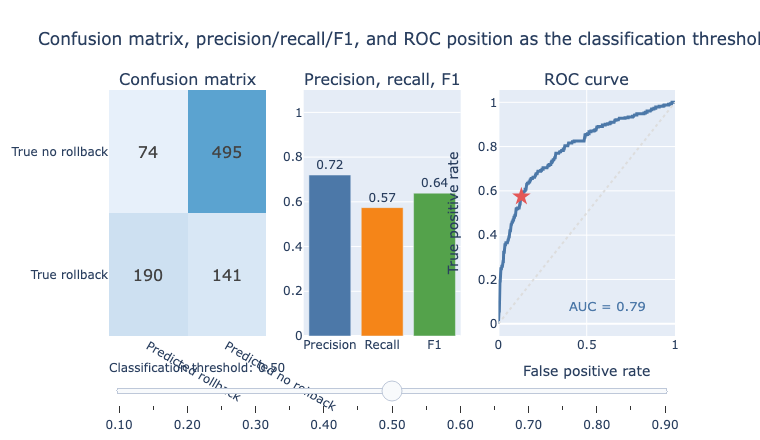

In [20]:
show(fig_confusion_threshold())